In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from types import SimpleNamespace
from IPython.display import HTML, display

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Time New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


# Adaptive time stepping test

In [32]:
eps = 3
t_ini = 0
data_path = Path(f"data/03_mrSAV_varstep_exp_data_{eps}_{t_ini}.npz")

## Load precomputed data

The simulation part has been moved to `03_run_mrsav_varstep_exp.py`.
Run `python 03_run_mrsav_varstep_exp.py --force` to regenerate `data/03_mrSAV_varstep_exp_data.npz`.


In [33]:
def tol_key(rtol, rtol_q):
    return (float(f"{rtol:.12g}"), float(f"{rtol_q:.12g}"))


def _scalar_string(value):
    return str(np.asarray(value).item())


def load_varstep_results(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Missing data file: {path}. Run `python 03_run_mrsav_varstep_exp.py --force` first."
        )

    data = np.load(path, allow_pickle=False)
    if int(data["adaptive_cache_version"]) < 5:
        raise ValueError(
            "Adaptive error definitions are outdated. Rerun "
            "`python 03_run_mrsav_varstep_exp.py --force`."
        )

    params = {
        "nu": float(data["nu"]),
        "m": int(data["m"]),
        "eps": float(data["eps"]),
        "t_ini": float(data["t_ini"]),
        "gam": float(data["gam"]),
        "s_domain": tuple(data["s_domain"].tolist()),
        "discrete_num": data["discrete_num"].astype(int).tolist(),
        "t_period": tuple(data["t_period"].tolist()),
        "ref_tau": float(data["ref_tau"]),
    }

    tol_grid_list = list(zip(data["tol_grid_rtol"].tolist(), data["tol_grid_rtol_q"].tolist()))
    tol_perturb_list = list(zip(data["tol_perturb_rtol"].tolist(), data["tol_perturb_rtol_q"].tolist()))

    all_adaptive_results = []
    for i in range(int(data["adaptive_count"])):
        all_adaptive_results.append({
            "rtol": float(data[f"adaptive_{i}_rtol"]),
            "rtol_q": float(data[f"adaptive_{i}_rtol_q"]),
            "cpu_time": data[f"adaptive_{i}_cpu_time"],
            "step_count": int(data[f"adaptive_{i}_step_count"]),
            "tn": data[f"adaptive_{i}_tn"],
            "tau": data[f"adaptive_{i}_tau"],
            "ref_err": data[f"adaptive_{i}_ref_err"],
            "rel_err": data[f"adaptive_{i}_rel_err"],
            "controller_err": data[f"adaptive_{i}_controller_err"],
            "ref_err_p": data[f"adaptive_{i}_ref_err_p"],
        })

    adaptive_result_by_tol = {
        tol_key(res["rtol"], res["rtol_q"]): res
        for res in all_adaptive_results
    }
    requested_tols = {tol_key(*tol) for tol in tol_grid_list + tol_perturb_list}
    missing_tols = requested_tols - set(adaptive_result_by_tol)
    if missing_tols:
        missing_text = ", ".join(str(tol) for tol in sorted(missing_tols))
        raise ValueError(
            f"Incomplete adaptive data; missing tolerance pairs: {missing_text}. "
            "Rerun `python 03_run_mrsav_varstep_exp.py --force`."
        )
    tol_grid_results = [adaptive_result_by_tol[tol_key(*tol)] for tol in tol_grid_list]
    tol_perturb_results = [adaptive_result_by_tol[tol_key(*tol)] for tol in tol_perturb_list]

    fixed_results = []
    for i in range(int(data["fixed_count"])):
        fixed_results.append({
            "key": _scalar_string(data[f"fixed_{i}_key"]),
            "tau": float(data[f"fixed_{i}_tau"]),
            "tn": data[f"fixed_{i}_tn"],
            "tau_values": data[f"fixed_{i}_tau_values"],
            "q": data[f"fixed_{i}_q"],
            "cpu_time": data[f"fixed_{i}_cpu_time"],
            "ref_error": data[f"fixed_{i}_ref_error"],
        })

    ref_solution = {"tn": data["ref_tn"]}

    return {
        **params,
        "tol_grid_list": tol_grid_list,
        "tol_perturb_list": tol_perturb_list,
        "all_adaptive_results": all_adaptive_results,
        "tol_grid_results": tol_grid_results,
        "tol_perturb_results": tol_perturb_results,
        "fixed_results": fixed_results,
        "ref_solution": ref_solution,
    }


loaded = load_varstep_results(data_path)
globals().update(loaded)

# assert len(tol_grid_results) == 9
# assert len(tol_perturb_results) == 9

# Backward-compatible aliases for any later ad-hoc cells.
solver_2h_fix_1 = SimpleNamespace(**fixed_results[0])
solver_2h_fix_2 = SimpleNamespace(**fixed_results[1])
solver_2h_fix_3 = SimpleNamespace(**fixed_results[2])
solver_2h_fix_5 = SimpleNamespace(**ref_solution)
ref_error_fix = fixed_results[0]["ref_error"]
ref_error_fix_2 = fixed_results[1]["ref_error"]
ref_error_fix_3 = fixed_results[2]["ref_error"]

print(f"Loaded data from {data_path}")
print(f"adaptive runs: {len(all_adaptive_results)}, fixed runs: {len(fixed_results)}")


Loaded data from data/03_mrSAV_varstep_exp_data_3_0.npz
adaptive runs: 9, fixed runs: 5


In [34]:
adaptive_styles = [
    {"color": "C0", "marker": "o", "linestyle": "-",  "offset": 0,   "zorder": 3},
    {"color": "C4", "marker": "^", "linestyle": "--", "offset": 80,  "zorder": 6},
    {"color": "C5", "marker": "v", "linestyle": "-.", "offset": 40,  "zorder": 5},
    {"color": "C6", "marker": "P", "linestyle": ":",  "offset": 120, "zorder": 4},
    {"color": "#2E8B57", "marker": "X", "linestyle": "-",  "offset": 160, "zorder": 7},
    {"color": "C8", "marker": "D", "linestyle": "--", "offset": 200, "zorder": 8},
    {"color": "C7", "marker": "h", "linestyle": "-.", "offset": 240, "zorder": 9},
    {"color": "black", "marker": "<", "linestyle": ":", "offset": 280, "zorder": 10},
    {"color": "goldenrod", "marker": ">", "linestyle": "-",  "offset": 320, "zorder": 11},
]

def _latex_scientific(value):
    mantissa, exponent = f"{value:.1e}".split("e")
    return rf"{mantissa}\times 10^{{{int(exponent)}}}"

def adaptive_label(res):
    rtol = _latex_scientific(res["rtol"])
    rtol_q = _latex_scientific(res["rtol_q"])
    return rf"Ada. $({rtol}, {rtol_q})$"

if len(all_adaptive_results) > len(adaptive_styles):
    raise ValueError(
        f"Need {len(all_adaptive_results)} adaptive markers, but only "
        f"{len(adaptive_styles)} adaptive styles are defined."
    )

adaptive_style_by_tol = {
    tol_key(res["rtol"], res["rtol_q"]): adaptive_styles[i]
    for i, res in enumerate(all_adaptive_results)
}

def adaptive_style(res):
    return adaptive_style_by_tol[tol_key(res["rtol"], res["rtol_q"])]


fixed_styles = [
    {"color": "C1", "marker": "*", "linestyle": "-.", "markevery": 400},
    {"color": "C8", "marker": "d", "linestyle": "--", "markevery": 800},
    {"color": "C9", "marker": "p", "linestyle": "--", "markevery": 800},
    {"color": "C3", "marker": "s", "linestyle": ":",  "markevery": 800},
    {"color": "#6A5ACD", "marker": "8", "linestyle": ":",  "markevery": 800},
]

if len(fixed_results) > len(fixed_styles):
    raise ValueError(
        f"Need {len(fixed_results)} fixed-step styles, but only "
        f"{len(fixed_styles)} fixed styles are defined."
    )

for res, style in zip(fixed_results, fixed_styles):
    res["plot_style"] = style

def fixed_style(res):
    return res["plot_style"]

def validate_unique_markers(adaptive_results):
    adaptive_markers = [adaptive_style(res)["marker"] for res in adaptive_results]
    fixed_markers = [fixed_style(res)["marker"] for res in fixed_results]
    all_markers = adaptive_markers + fixed_markers
    if len(all_markers) != len(set(all_markers)):
        duplicates = sorted({marker for marker in all_markers if all_markers.count(marker) > 1})
        raise ValueError(f"Repeated markers found: {duplicates}")


def plot_adaptive(ax, y, adaptive_results, markevery=300, label=False):
    for res in adaptive_results:
        style = adaptive_style(res)
        mark = (style["offset"], markevery)
        values = np.asarray(y(res))
        times = res["tn"] if len(values) == len(res["tn"]) else res["tn"][1:]
        if len(values) != len(times):
            raise ValueError(f"Cannot align tn ({len(res['tn'])}) with data ({len(values)})")
        ax.plot(times[2:], values[2:], color=style["color"], marker=style["marker"],
                linestyle=style["linestyle"], linewidth=1, markersize=4,
                markeredgewidth=0, markevery=mark, zorder=style["zorder"],
                label=adaptive_label(res) if label else None)


def zero_at_time(t, y, t0=0.0):
    i0 = int(np.argmin(np.abs(t - t0)))
    return y - y[i0]


def plot_comparison(adaptive_results, output_path, legend_ncol=4, legend_bbox=(0.5, 0.37)):
    validate_unique_markers(adaptive_results)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig = plt.figure(figsize=(17, 15))

    ax1 = plt.subplot2grid((6, 6), (0, 0), colspan=2, rowspan=2)
    plot_adaptive(ax1, lambda res: res["tau"], markevery=200, label=True, adaptive_results=adaptive_results)
    for res in fixed_results:
        style = fixed_style(res)
        ax1.plot(np.linspace(t_period[0], t_period[1], 61), np.ones(61) * res['tau'],
                 color=style['color'], marker=style['marker'], markeredgewidth=0, markersize=5,
                 linewidth=1, linestyle=style['linestyle'], label=rf"$\tau = {res['tau']:.3g}$")
    ax1.hlines(1e-2, 0, 60, colors='k', linestyles='dashed', alpha=0.5, linewidth=1)
    ax1.hlines(1e-5, 0, 60, colors='k', linestyles='dashed', alpha=0.5, linewidth=1)
    ax1.set_yscale("log")
    ax1.set_xlim(*t_period)
    # ax1.set_xlim(0,.1)
    ax1.set_xlabel(r"$t$", fontsize=15)
    ax1.set_ylabel(r"Step sizes", fontsize=12)
    ax1.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    ax6 = plt.subplot2grid((6, 6), (0, 2), colspan=2, rowspan=2)
    plot_adaptive(ax6, lambda res: zero_at_time(res["tn"], np.arange(len(res["tn"]))), adaptive_results=adaptive_results)
    for res in fixed_results:
        style = fixed_style(res)
        step_count = zero_at_time(res["tn"], np.arange(len(res["tn"])))
        ax6.plot(res['tn'], step_count, linewidth=1, color=style['color'],
                 marker=style['marker'], markeredgewidth=0, markersize=5,
                 markevery=style['markevery'], linestyle=style['linestyle'])
    ax6.set_xlim(*t_period)
    ax6.set_ylim(bottom=0)
    ax6.set_xlabel(r"$t$", fontsize=15)
    ax6.set_ylabel(r"Step count", fontsize=12)
    ax6.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    ax2 = plt.subplot2grid((6, 6), (0, 4), colspan=2, rowspan=2)
    plot_adaptive(ax2, lambda res: zero_at_time(res["tn"], res["cpu_time"]), adaptive_results=adaptive_results)
    for res in fixed_results:
        style = fixed_style(res)
        cpu_time = zero_at_time(res["tn"], res["cpu_time"])
        ax2.plot(res['tn'], cpu_time, color=style['color'], marker=style['marker'],
                 markeredgewidth=0, markersize=5, markevery=style['markevery'],
                 linewidth=1, linestyle=style['linestyle'])
    ax2.set_xlim(*t_period)
    ax2.set_ylim(bottom=0)
    ax2.set_xlabel(r"$t$", fontsize=15)
    ax2.set_ylabel(r"CPU time (s)", fontsize=12)
    ax2.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    ax3 = plt.subplot2grid((6, 6), (2, 0), colspan=2, rowspan=2)
    plot_adaptive(ax3, lambda res: res["ref_err_p"], markevery=200, adaptive_results=adaptive_results)
    for res in fixed_results:
        style = fixed_style(res)
        ax3.plot(res['tn'], np.abs(res['q'] - 1), marker=style['marker'], markeredgewidth=0,
                 markersize=5, markevery=style['markevery'], linewidth=1,
                 color=style['color'], linestyle=style['linestyle'])
    # ax3.hlines(1e-4, 0, 60, colors='k', linestyles='dashed', alpha=0.5, linewidth=1)
    ax3.set_yscale("log")
    ax3.set_xlim(*t_period)
    ax3.set_ylim(1e-9, 1e1)
    ax3.set_xlabel(r"$t$", fontsize=15)
    ax3.set_ylabel(r"$| r |$", fontsize=12)
    ax3.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    ax4 = plt.subplot2grid((6, 6), (2, 2), colspan=2, rowspan=2)
    plot_adaptive(ax4, lambda res: res["rel_err"], adaptive_results=adaptive_results)
    # ax4.hlines(1e-4, 0, 60, colors='k', linestyles='dashed', alpha=0.5, linewidth=1)
    ax4.set_yscale("log")
    ax4.set_xlim(*t_period)
    ax4.set_ylim(1e-7, 1e-2)
    # ax4.set_yticks([1e-8, 1e-6, 1e-4, 1e-2])
    ax4.set_xlabel(r"$t$", fontsize=15)
    ax4.set_ylabel(r"Relative $L^2$ error of Vorticity", fontsize=12)
    ax4.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    ax5 = plt.subplot2grid((6, 6), (2, 4), colspan=2, rowspan=2)
    plot_adaptive(ax5, lambda res: res["ref_err"], adaptive_results=adaptive_results)
    for res in fixed_results:
        style = fixed_style(res)
        ax5.plot(res["tn"][1:], res['ref_error'][1:], linewidth=1, color=style['color'], marker=style['marker'],
                 markeredgewidth=0, markersize=5, markevery=500, linestyle=style['linestyle'])
    # ax5.hlines(1e-3, 0, 20, colors='k', linestyles='dashed', alpha=0.5, linewidth=1)
    ax5.set_yscale("log")
    ax5.set_xlim(*t_period)
    ax5.set_ylim(1e-7, 1e1)
    ax5.set_yticks([1e-6, 1e-4, 1e-2, 1e0])
    ax5.set_xlabel(r"$t$", fontsize=15)
    ax5.set_ylabel(r"Reference relative $L^2$ error of Vorticity", fontsize=12)
    ax5.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    # 子图标签：按布局顺序 (a)-(f)
    for label, ax_sub in zip(['(a)', '(b)', '(c)', '(d)', '(e)', '(f)'], [ax1, ax6, ax2, ax3, ax4, ax5]):
        ax_sub.text(x=0.5, y=-0.21, s=label, transform=ax_sub.transAxes,
                    fontsize=18, fontweight='bold', ha='center', va='center')

    fig.legend(loc="lower center", ncol=legend_ncol, fontsize=13, bbox_to_anchor=legend_bbox)
    fig.tight_layout(rect=[0, 0.18, 1, 1])
    fig.savefig(output_path, bbox_inches='tight', dpi=300)
    return fig


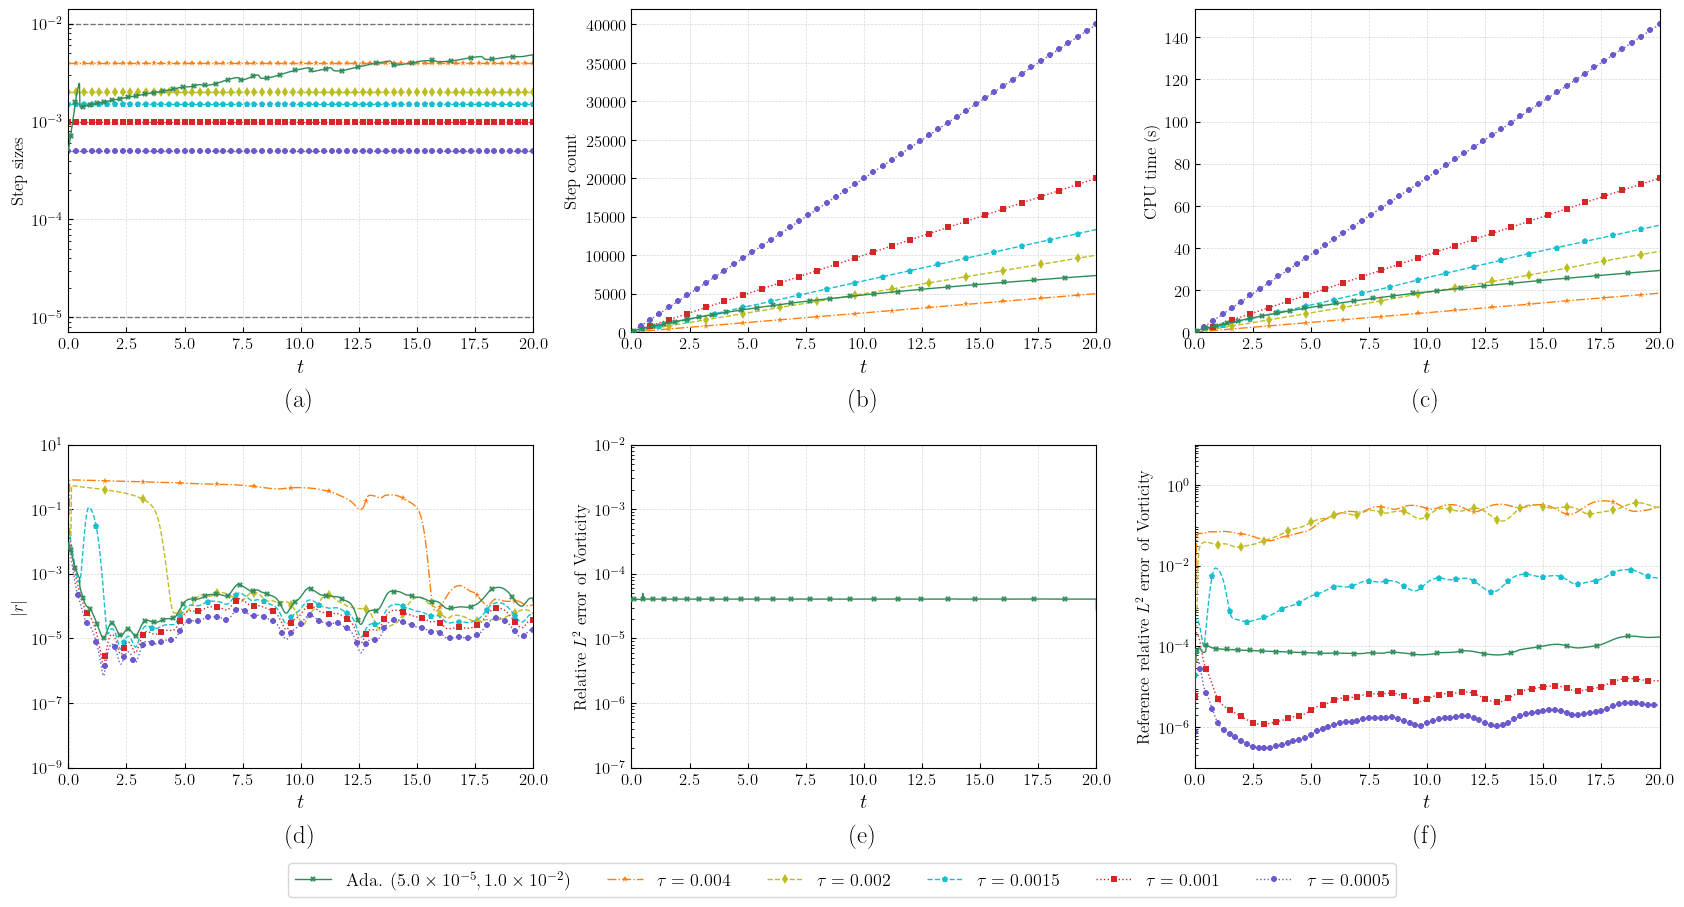

In [35]:
fig_tol_grid = plot_comparison(tol_grid_results, "fig/adaptive_step_tol_grid_0_20.pdf", legend_ncol=6, legend_bbox=(0.5, 0.39))

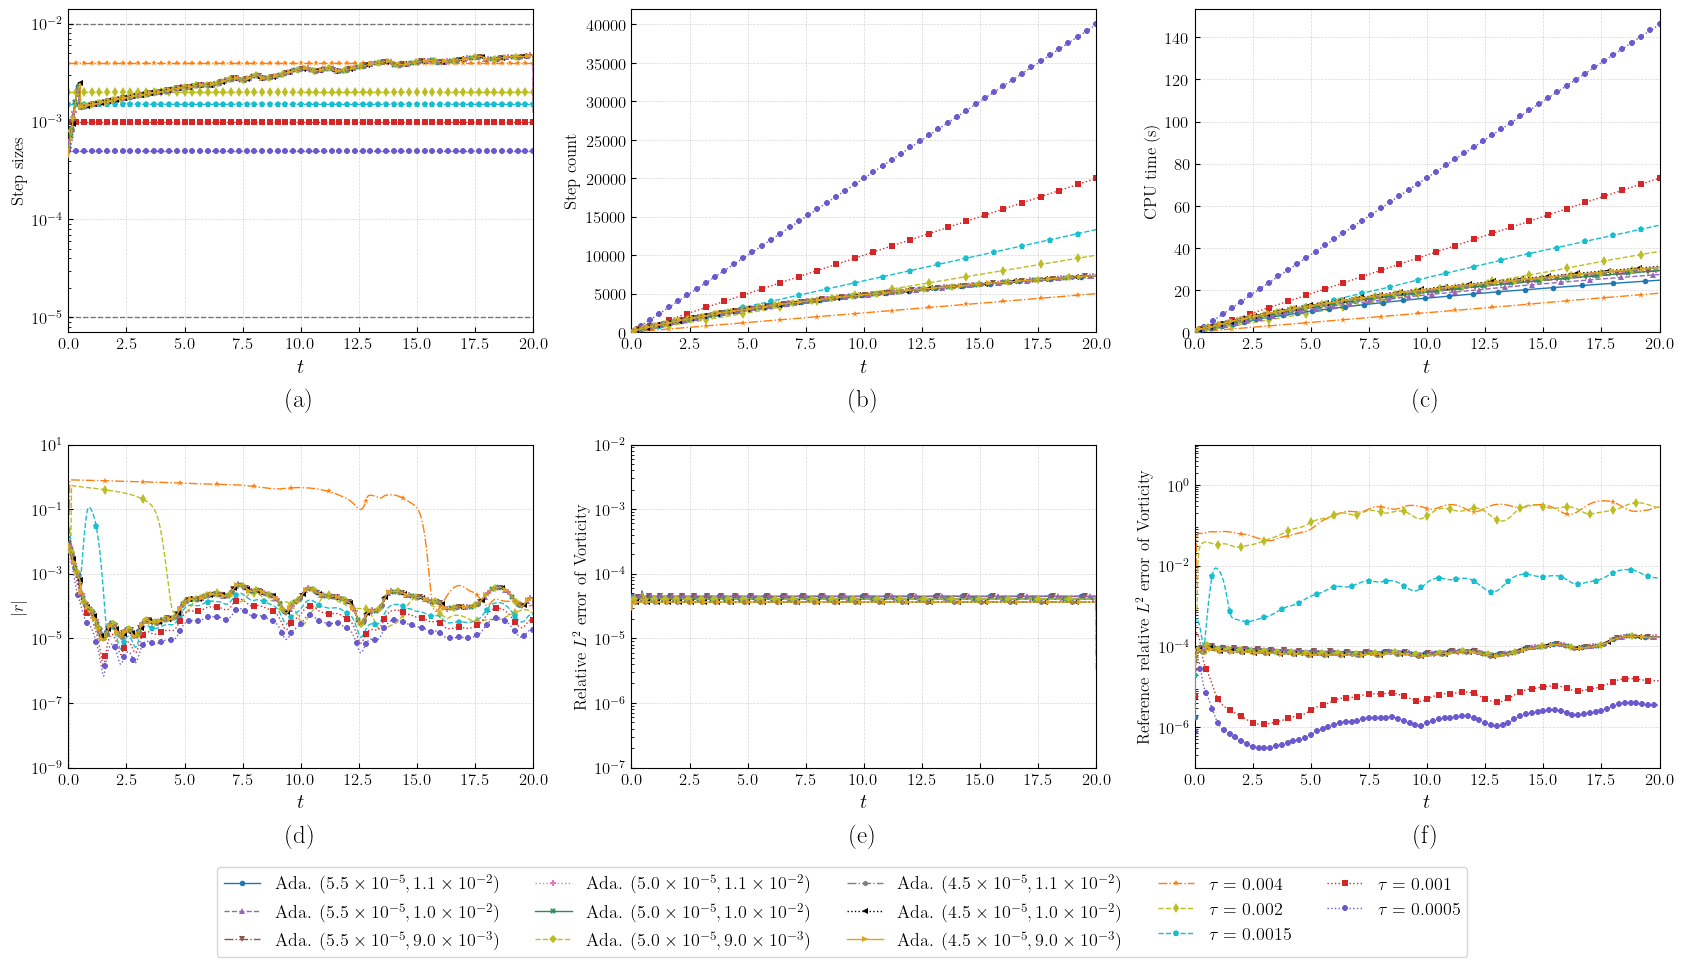

In [36]:
fig_tol_perturb = plot_comparison(tol_perturb_results, "fig/adaptive_step_tol_perturb_0_20.pdf", legend_ncol=5, legend_bbox=(0.5, 0.35))